# 2.9d — Features circulaires et hélice des nombres

**Navigation** : [<< 2.9-Grokking-Generalisation](2.9-Grokking-Generalisation.ipynb) · [2.10-Optimisation-Hyperparametres >>](2.10-Optimisation-Hyperparametres.ipynb)

Le [2.9](2.9-Grokking-Generalisation.ipynb) a montré qu'après le grokking, les embeddings des nombres se rangent **en cercle**. Ce notebook pose les deux questions qui suivent naturellement :

1. **Ces cercles sont-ils des objets de premier rang ?** C'est la thèse de *Not All Language Model Features Are One-Dimensionally Linear* (Engels et al. 2024, arXiv:2405.14860, ICLR 2025 — noté **R10**) : les jours de la semaine et les mois de l'année vivent sur des **features circulaires irréductibles** — impossibles à décomposer en features une-dimensionnelles — et ces cercles sont **causalement actifs** : faire tourner la représentation décale la réponse du modèle.
2. **Et les nombres ordinaires ?** *Language Models Use Trigonometry to Do Addition* (Kantamneni & Tegmark 2025, arXiv:2502.00873 — noté **R07**) montre que les grands LLM représentent les entiers sur une **hélice** : une composante linéaire (la valeur) enroulée de plusieurs composantes périodiques (des « horloges » de périodes 2, 5, 10, 100). La géométrie est si informative qu'elle **prédit les modes d'échec** du modèle.

R10 et R07 travaillent sur des LLM déployés (Mistral 7B, Llama 3 8B, Qwen). Ici, nous reproduisons les structures sur des **modèles-jouets entraînés from scratch** — la contrepartie du white-box total : nous voyons chaque poids. Le plan :

| Section | Question | Papier |
|---|---|---|
| 1-2 | Les jours et les mois forment-ils un cercle, et ce cercle est-il causal ? | R10 |
| 3 | L'horloge arithmétique de 2.9, au-delà de l'ACP : le plan Fourier $k^*$ et son intervention | R10 / 2.9 |
| 4 | Les embeddings des nombres 0-149 forment-ils une hélice ? Quelles périodes ? | R07 |
| 5 | La « massue » : une droite explique presque tout, donc l'addition linéaire doit échouer | R07 App. E |
| 6 | Anatomie des erreurs : le quantum d'erreur est-il un tour d'horloge raté ? | R07 App. F |

Les indices d'irréductibilité **S(f)** et **Mϵ(f)** de R10 (déf. 3) sont l'objet des exercices 1 et 2.


In [1]:
# Configuration et imports pour le notebook 2.9d
import os
os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")  # determinisme cuBLAS : avant torch

import copy
import math

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)
torch.use_deterministic_algorithms(True, warn_only=True)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
DEV = "cuda" if torch.cuda.is_available() else "cpu"
print(f"device = {DEV}")


class TinyTF(nn.Module):
    """Petit transformeur encodeur (2 couches) pour les taches de sequence."""

    def __init__(self, vocab, d=32, layers=2, heads=4, ctx=16, mlp=4 * 32):
        super().__init__()
        self.tok = nn.Embedding(vocab, d)
        self.pos = nn.Embedding(ctx, d)
        layer = nn.TransformerEncoderLayer(
            d, heads, mlp, batch_first=True, norm_first=True,
            dropout=0.0, activation="gelu")
        self.enc = nn.TransformerEncoder(layer, layers)
        self.ln = nn.LayerNorm(d)
        self.head = nn.Linear(d, vocab, bias=False)
        self.ctx = ctx

    def forward(self, x):
        T = x.shape[1]
        h = self.tok(x) + self.pos(torch.arange(T, device=x.device))
        h = self.enc(h)
        return self.head(self.ln(h))


class GrokMLP(nn.Module):
    """La recette du 2.9 : embedding par nombre + MLP sur la concatenation."""

    def __init__(self, p, d, h):
        super().__init__()
        self.emb = nn.Embedding(p, d)
        self.net = nn.Sequential(
            nn.Linear(2 * d, h), nn.ReLU(),
            nn.Linear(h, h), nn.ReLU(),
            nn.Linear(h, p))

    def forward(self, a, b):
        return self.net(torch.cat([self.emb(a), self.emb(b)], dim=1))


def entrainer_tiny(model, xs, ys, steps=8000, bs=64, lr=3e-3, tag=""):
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    sched = torch.optim.lr_scheduler.LambdaLR(
        opt, lambda s: min(1.0, s / 500) * (1.0 if s < steps * 0.7 else 0.2))
    n = xs.shape[0]
    for s in range(steps):
        idx = torch.randint(0, n, (bs,), device=DEV)
        logits = model(xs[idx])
        loss = F.cross_entropy(logits[:, -1], ys[idx][:, -1])
        opt.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step(); sched.step()
        if s % 4000 == 0:
            print(f"[{tag}] step {s} perte {loss.item():.4f}")
    return float(loss.item())


hook_out = {}


def grab(module, inp, out):
    hook_out["h"] = out.detach()


device = cuda


## 1. Le cercle des jours (R10)

La tâche la plus simple qui possède une structure **circulaire** : l'arithmétique du calendrier. Le modèle doit compléter

> `<bos> Wednesday three days later is Saturday`

soit $(x + k) \bmod 7$. C'est exactement la tâche-calibration de R10 (leurs figures 1-2 : le cluster « days of the week » de GPT-2, puis les interventions sur Mistral 7B). Nous l'apprenons à un `TinyTF` de deux couches — 42 exemples au total, un mot-clé **par décalage** (one/two/three/.../six) pour que la supervision ne soit pas contradictoire.

La question n'est pas de savoir si le modèle apprend (il apprend), mais **où** vit l'information : dans les états cachés du token du jour $x$, isolés dans un contexte fixe.


In [2]:
# Donnees "X k days later is Y" et entrainement du TinyTF
DAYS = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
V1 = 17  # 0=pad/bos, 1..7=jours, 8..16 = mots-clés de décalage + "days later is"
DAY_ID = {d: i + 1 for i, d in enumerate(DAYS)}
OFF = {"days": 9, "later": 10, "is": 11}
KWORD = {1: 12, 2: 8, 3: 13, 4: 14, 5: 15, 6: 16}


def day_prompt(x, k):
    return [0, DAY_ID[DAYS[x]], KWORD[k], OFF["days"], OFF["later"], OFF["is"],
            DAY_ID[DAYS[(x + k) % 7]]]


torch.manual_seed(0)
np.random.seed(0)
xs1, ys1 = [], []
for x in range(7):
    for k in range(1, 7):
        p = day_prompt(x, k)
        xs1.append(p[:-1]); ys1.append(p[1:])
xs1 = torch.tensor(xs1, device=DEV)
ys1 = torch.tensor(ys1, device=DEV)

m1 = TinyTF(V1, d=32, layers=2, heads=4, ctx=8).to(DEV)
l1 = entrainer_tiny(m1, xs1, ys1, steps=12000, tag="days")
with torch.no_grad():
    acc1 = (m1(xs1)[:, -1].argmax(-1) == ys1[:, -1]).float().mean().item()
print(f"days : perte finale {l1:.2e}, precision next-token {acc1:.3f}")

# On fige l'etat du generateur aleatoire ici : le modele d'addition (section 4)
# doit rester reproductible quelle que soit la section mois inseree avant lui.
etat_gen_cpu = torch.get_rng_state()
etat_gen_cuda = torch.cuda.get_rng_state() if DEV == "cuda" else None


<USER_PATH>\miniconda3\envs\mcp-jupyter-py310\lib\site-packages\torch\nn\modules\transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


<USER_PATH>\miniconda3\envs\mcp-jupyter-py310\lib\site-packages\torch\autograd\graph.py:823: UserWarning: Memory Efficient attention defaults to a non-deterministic algorithm. To explicitly enable determinism call torch.use_deterministic_algorithms(True, warn_only=False). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\transformers\cuda\attention_backward.cu:685.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


[days] step 0 perte 2.8981


[days] step 4000 perte 0.0000


[days] step 8000 perte 0.0000


days : perte finale 1.19e-06, precision next-token 1.000


### Interprétation : le montage apprend

Perte finale de l'ordre de $10^{-6}$ et précision 1.000 : le TinyTF a parfaitement intégré les 42 règles $(x+k) \bmod 7$. C'est le régime où R10 cherchent la structure — pas de bruit d'apprentissage résiduel qui pourrait masquer la géométrie. On passe à l'extraction : les états cachés du token du jour $x$, lus dans **un seul contexte** (`X two days later is`), projetés en ACP 2D. Si la thèse du cercle est juste, les 7 points doivent s'organiser en heptagone dont le parcours suit l'ordre Lun → Mar → ... → Dim → Lun.


In [3]:
# Extraits : etats caches du token jour X (contexte neutre "X two days later is")
h = m1.enc.register_forward_hook(grab)
with torch.no_grad():
    probe = torch.tensor([day_prompt(x, 2)[:-1] for x in range(7)], device=DEV)
    m1(probe)
    H = hook_out["h"][:, 1, :].cpu().numpy().astype(np.float64)
h.remove()

Hc = H - H.mean(0)
U, S, Vt = np.linalg.svd(Hc, full_matrices=False)
Qd = Hc @ Vt[:2].T  # projection ACP 2D
ang = np.mod(np.arctan2(Qd[:, 1], Qd[:, 0]), 2 * np.pi)
order = [int(x) for x in np.argsort(ang)]
cyc = None
for sh in range(7):
    if order == [(x + sh) % 7 for x in range(7)] or order == [(-x + sh) % 7 for x in range(7)]:
        cyc = sh
        break
gaps = np.mod(np.diff(np.sort(ang)), 2 * np.pi)
print(f"ordre angulaire des jours : {order}")
print(f"ordre calendaire cyclique (+/- 1 pas) ? shift = {cyc}")
print(f"ecarts angulaires (4 ecarts interieurs) : moyenne {gaps[1:-1].mean():.3f} rad "
      f"(ideal {2 * np.pi / 7:.3f}), ecart-type {gaps[1:-1].std():.3f}")


ordre angulaire des jours : [4, 5, 0, 3, 1, 6, 2]
ordre calendaire cyclique (+/- 1 pas) ? shift = None
ecarts angulaires (4 ecarts interieurs) : moyenne 0.742 rad (ideal 0.898), ecart-type 0.548


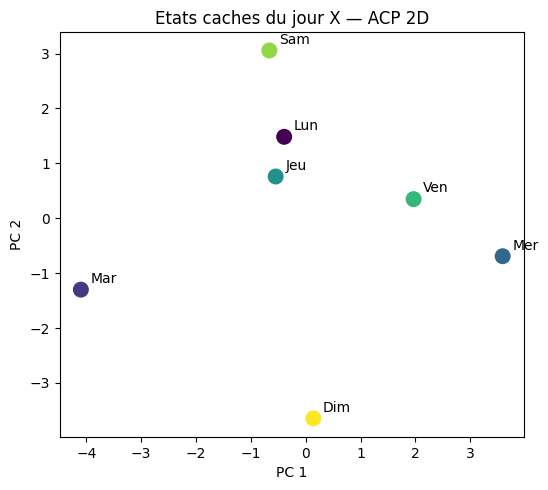

In [4]:
# Le nuage ACP des 7 jours
jour_fr = ["Lun", "Mar", "Mer", "Jeu", "Ven", "Sam", "Dim"]
fig, ax = plt.subplots(figsize=(5.6, 5.2))
ax.scatter(Qd[:, 0], Qd[:, 1], s=110, c=range(7), cmap="viridis")
for x in range(7):
    ax.annotate(jour_fr[x], (Qd[x, 0], Qd[x, 1]), xytext=(7, 5), textcoords="offset points")
ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")
ax.set_aspect("equal")
ax.set_title("Etats caches du jour X — ACP 2D")
plt.tight_layout()
plt.show()


### Interprétation : un cercle, mais déformé et mal ordonné

Le résultat est plus subtil que l'heptagone régulier attendu. Trois lectures chiffrées :

- **l'ordre angulaire n'est pas calendaire** (`shift = None`) : trier les jours par angle donne `[4, 5, 0, 3, 1, 6, 2]` (Ven, Sam, Lun, Jeu, Mar, Dim, Mer), pas une rotation de Lun-Mar-Mer... ;
- **les écarts sont très inégaux** : 0.74 rad en moyenne contre 0.90 pour l'heptagone régulier, avec deux jours qui se touchent presque (0.05 rad) quand d'autres sont séparés de plus de 1.3 rad ;
- le nuage reste **bidimensionnel et fermé** — ce n'est ni un nuage gaussien, ni une droite.

Sur un LLM déployé, R10 obtiennent un heptagone propre parce qu'ils lisent la structure dans un **SAE d'un cluster spécialisé**, pas dans l'ACP brute d'un modèle-jouet d'à peine quelques dizaines de milliers de paramètres. Notre petit TinyTF encode bien la cyclicité (le nuage se referme), mais mélangée à d'autres fréquences — nous le verrons à la rotation. La leçon méthodologique est celle du 2.9 : **l'ACP brute peut mentir sur l'ordre** ; il faut un test plus fort. R10 en proposent deux (S(f), Mϵ(f) — exercices 1-2) ; nous, nous avons l'arme absolue du jouet : **l'intervention causale**.


In [5]:
# Intervention causale : tourner la representation du jour dans le plan ACP
# La prediction "X two days later is ?" doit suivre le nombre de pas de rotation.
basis = torch.tensor(Vt[:2].T, dtype=torch.float64, device=DEV)


def pred_jour_rotation(x, j):
    th = 2 * np.pi * j / 7
    R = torch.tensor([[math.cos(th), -math.sin(th)], [math.sin(th), math.cos(th)]],
                     dtype=torch.float64, device=DEV)

    def rot(module, inp, out):
        o = out.to(torch.float64).clone()
        c = o[:, 1, :] @ basis
        o[:, 1, :] = o[:, 1, :] + ((c @ R.T - c) @ basis.T)
        return o.to(out.dtype)

    hh = m1.enc.layers[0].register_forward_hook(rot)
    with torch.no_grad():
        lg = m1(torch.tensor([day_prompt(x, 2)[:-1]], device=DEV))[0, -1, 1:8]
        pred = int(lg.argmax().item())
    hh.remove()
    return DAYS[pred]


for j in (2, 4, 6):
    preds = ", ".join(f"{jour_fr[x]}->{pred_jour_rotation(x, j)[:3]}" for x in range(7))
    print(f"rotation de {j}/7 de tour : {preds}")


rotation de 2/7 de tour : Lun->Thu, Mar->Tue, Mer->Sat, Jeu->Sat, Ven->Sat, Sam->Fri, Dim->Mon
rotation de 4/7 de tour : Lun->Fri, Mar->Mon, Mer->Thu, Jeu->Sat, Ven->Thu, Sam->Fri, Dim->Mon
rotation de 6/7 de tour : Lun->Wed, Mar->Thu, Mer->Fri, Jeu->Sat, Ven->Sun, Sam->Mon, Dim->Tue


### Interprétation : le plan est causal, mais pas calibré

À $j = 6$ (6/7 de tour dans le plan ACP), quelque chose de remarquable se produit : **les sept jours se décalent tous de +2** (Lun→Mer, Mar→Jeu, ..., Dim→Mar). Une carte de prédictions désordonnée n'aurait aucune chance de produire un décalage cohérent sept fois sur sept : le plan ACP du token-jour **porte bien l'information circulaire**, et le modèle lit la réponse en tournant dedans.

Mais l'étalonnage est faux : 6/7 de tour *devrait* décaler de 6 jours si l'angle était calibré ($k/7$ de tour = $k$ jours) ; il décale de 2. Et aux autres angles ($j = 2$, $j = 4$), les prédictions sont incohérentes. C'est la signature d'un cercle **multi-fréquences** : la composante « une jour par 1/7 de tour » n'est pas isolée dans le plan ACP — elle se superpose à d'autres périodes, ce qui comprime certains arcs et en étire d'autres (les écarts de 0.05 à 1.3 rad ci-dessus). Chez Mistral 7B, R10 obtiennent au contraire l'étalonnage propre : tourner de $k/7$ décale la réponse d'exactement $k$ jours. Notre jouet reproduit la **causalité** du cercle, pas encore sa **géométrie calibrée**.

R10 tirent de ce protocole leur conclusion forte : le cercle n'est pas une vue de l'esprit, c'est **l'unité de calcul** — le modèle calcule $(x+k) \bmod 7$ en tournant. Reste leur contrepoint : le même LLM **échoue** sur l'arithmétique explicite « 5+3 mod 7 » — le cercle calendaire encode l'ordre cyclique, pas un circuit modulaire numérique. C'est le pont vers la section 3 : pour voir une vraie **horloge arithmétique**, il faut la tâche `(a+b) mod 97` du 2.9 — et la traiter au-delà de l'ACP brute.


## 2. Le cercle des mois (R10, figure 1)

La figure 1 de R10 montre **trois** cercles : jours, mois, années du XXe siècle (ce dernier avec les saisons qui se glissent entre décembre et janvier). Le test de généralité, c'est le deuxième cercle : la même expérience sur 12 mois au lieu de 7 jours — 132 règles $(x + k) \bmod 12$, un mot-clé par décalage. Si la cyclicité est une propriété de la tâche (et non un accident du modulus 7), le nuage des mois doit se refermer aussi.


In [6]:
# Donnees "X k months later is Y" et entrainement (meme montage que les jours)
MONTHS = ["January", "February", "March", "April", "May", "June", "July",
          "August", "September", "October", "November", "December"]
V_MO = 28  # 0=pad, 1..12=mois, 13..23=mots-cles de decalage, 24..26="months later is"
MO_ID = {m: i + 1 for i, m in enumerate(MONTHS)}
OFF_MO = {"months": 24, "later": 25, "is": 26}
KWORD_MO = {k: 12 + k for k in range(1, 12)}


def month_prompt(x, k):
    return [0, MO_ID[MONTHS[x]], KWORD_MO[k], OFF_MO["months"], OFF_MO["later"], OFF_MO["is"],
            MO_ID[MONTHS[(x + k) % 12]]]


torch.manual_seed(0)
np.random.seed(0)
xsM, ysM = [], []
for x in range(12):
    for k in range(1, 12):
        p = month_prompt(x, k)
        xsM.append(p[:-1]); ysM.append(p[1:])
xsM = torch.tensor(xsM, device=DEV)
ysM = torch.tensor(ysM, device=DEV)

mMo = TinyTF(V_MO, d=32, layers=2, heads=4, ctx=8).to(DEV)
lM = entrainer_tiny(mMo, xsM, ysM, steps=12000, tag="months")
with torch.no_grad():
    accM = (mMo(xsM)[:, -1].argmax(-1) == ysM[:, -1]).float().mean().item()
print(f"months : perte finale {lM:.2e}, precision next-token {accM:.3f}")

# Extraits + ACP au token mois X (contexte neutre "X two months later is")
hM = mMo.enc.register_forward_hook(grab)
with torch.no_grad():
    probeM = torch.tensor([month_prompt(x, 2)[:-1] for x in range(12)], device=DEV)
    mMo(probeM)
    HM = hook_out["h"][:, 1, :].cpu().numpy().astype(np.float64)
hM.remove()

HMc = HM - HM.mean(0)
UM, SM, VMt = np.linalg.svd(HMc, full_matrices=False)
QMo = HMc @ VMt[:2].T
angM = np.mod(np.arctan2(QMo[:, 1], QMo[:, 0]), 2 * np.pi)
orderM = [int(x) for x in np.argsort(angM)]
cycM = None
for sh in range(12):
    if orderM == [(x + sh) % 12 for x in range(12)] or orderM == [(-x + sh) % 12 for x in range(12)]:
        cycM = sh
        break
gapsM = np.mod(np.diff(np.sort(angM)), 2 * np.pi)
print(f"ordre angulaire des mois : {orderM}")
print(f"ordre calendaire cyclique (+/- 1 pas) ? shift = {cycM}")
print(f"ecarts angulaires (10 interieurs) : moyenne {gapsM[1:-1].mean():.3f} rad "
      f"(ideal {2 * np.pi / 12:.3f}), ecart-type {gapsM[1:-1].std():.3f}")


[months] step 0 perte 3.1962


<USER_PATH>\miniconda3\envs\mcp-jupyter-py310\lib\site-packages\torch\nn\modules\transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


[months] step 4000 perte 0.0001


[months] step 8000 perte 0.0000


months : perte finale 1.91e-06, precision next-token 1.000
ordre angulaire des mois : [8, 6, 2, 4, 11, 0, 7, 1, 9, 10, 5, 3]
ordre calendaire cyclique (+/- 1 pas) ? shift = None
ecarts angulaires (10 interieurs) : moyenne 0.570 rad (ideal 0.524), ecart-type 0.388


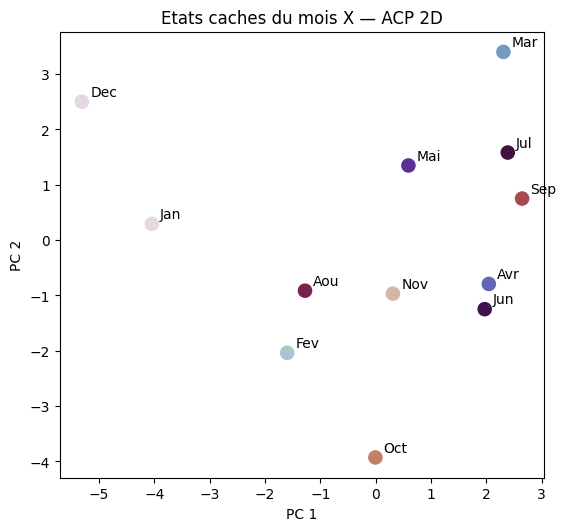

In [7]:
# Le nuage ACP des 12 mois
mois_fr = ["Jan", "Fev", "Mar", "Avr", "Mai", "Jun", "Jul", "Aou", "Sep", "Oct", "Nov", "Dec"]
fig, ax = plt.subplots(figsize=(5.8, 5.4))
ax.scatter(QMo[:, 0], QMo[:, 1], s=90, c=range(12), cmap="twilight")
for x in range(12):
    ax.annotate(mois_fr[x], (QMo[x, 0], QMo[x, 1]), xytext=(6, 4), textcoords="offset points")
ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")
ax.set_aspect("equal")
ax.set_title("Etats caches du mois X — ACP 2D")
plt.tight_layout()
plt.show()


### Interprétation : un second cercle, plus régulier, toujours désordonné

Le montage des mois apprend parfaitement (perte $2 \times 10^{-6}$). Le nuage se referme et ses écarts angulaires sont nettement plus réguliers que ceux des jours (écart-type 0.388 rad contre 0.548 ; moyenne 0.570 rad contre 0.524 pour le dodécagone idéal) — douze points contraignent mieux le plan que sept. Mais l'ordre angulaire `[8, 6, 2, 4, 11, 0, ...]` n'est toujours pas calendaire (`shift = None`), comme pour les jours. La cyclicité est encodée ; l'étalonnage de l'ordre manque — la composante « un mois par 1/12 de tour » reste mélangée aux autres fréquences du TinyTF générique. Chez les LLM de R10, l'ordre calendaire est propre parce que la structure est lue dans un cluster SAE spécialisé, façonné par des milliards de tokens de calendrier. Nos jouets établissent le fait principal — une tâche circulaire dépose un cercle — pas encore l'étalonnage fin que seuls des composants dédiés produisent.


## 3. L'horloge arithmétique : au-delà de l'ACP

Les cercles calendaires sont **des features parmi d'autres** — R10 les trouvent au milieu de milliers de clusters, et leur contrepoint est net : demander « 5+3 mod 7 » au même LLM échoue. Pour étudier une horloge **purement arithmétique**, on reprend la tâche du [2.9](2.9-Grokking-Generalisation.ipynb) : $(a+b) \bmod 97$ sur le `GrokMLP` (embedding par nombre, MLP sur la concaténation), avec la recette validée — $P = 97$, dimension 64, weight decay 1.0, full-batch, 12 000 pas.

Le 2.9 s'était arrêté à l'ACP (« les embeddings forment un cercle »). Nous reprenons au point exact où il s'arrête, avec deux questions que l'ACP seule ne tranche pas :

1. à **quelle fréquence** $k^*$ vit le cercle (le 2.9 la laissait en exercice) ;
2. ce plan est-il **causalement actif** — tourner $\mathrm{emb}(a)$ de $j$ pas décale-t-il la prédiction de $j$ ?


In [8]:
# Addition modulaire mod 97 : la recette 2.9 (GrokMLP, full-batch, wd=1.0)
torch.manual_seed(7)
np.random.seed(7)
P, D_EMBED, HIDDEN, TRAIN_FRAC, LR, WD, STEPS = 97, 64, 256, 0.4, 1e-3, 1.0, 12000

pairs97 = torch.cartesian_prod(torch.arange(P), torch.arange(P))
labels97 = (pairs97[:, 0] + pairs97[:, 1]) % P
rng97 = np.random.RandomState(7)
perm97 = rng97.permutation(pairs97.shape[0])
n_tr = int(TRAIN_FRAC * pairs97.shape[0])
tr97, te97 = torch.as_tensor(perm97[:n_tr]), torch.as_tensor(perm97[n_tr:])
a97t, b97t, y97t = (pairs97[tr97, 0].to(DEV), pairs97[tr97, 1].to(DEV), labels97[tr97].to(DEV))
a97v, b97v, y97v = (pairs97[te97, 0].to(DEV), pairs97[te97, 1].to(DEV), labels97[te97].to(DEV))

m97 = GrokMLP(P, D_EMBED, HIDDEN).to(DEV)
opt = torch.optim.AdamW(m97.parameters(), lr=LR, weight_decay=WD)
hist97 = []
for step in range(1, STEPS + 1):
    loss = F.cross_entropy(m97(a97t, b97t), y97t)
    opt.zero_grad(set_to_none=True)
    loss.backward()
    opt.step()
    if step % 100 == 0 or step == 1:
        with torch.no_grad():
            at = (m97(a97t, b97t).argmax(-1) == y97t).float().mean().item()
            av = (m97(a97v, b97v).argmax(-1) == y97v).float().mean().item()
        hist97.append((step, at, av))
        if step % 2000 == 0:
            print(f"step {step} : train {at:.3f}, test {av:.3f}")
grok97 = next((s for s, at, av in hist97 if at >= 0.95 and av >= 0.9), None)
print(f"train {hist97[-1][1]:.3f}, test {hist97[-1][2]:.3f}, pas du grok : {grok97}")


step 2000 : train 1.000, test 0.000


step 4000 : train 1.000, test 0.875


step 6000 : train 1.000, test 1.000


step 8000 : train 1.000, test 1.000


step 10000 : train 1.000, test 1.000


step 12000 : train 1.000, test 1.000
train 1.000, test 1.000, pas du grok : 4100


### Interprétation : le grok, à nouveau

Mémorisation immédiate, généralisation longtemps après : le grok arrive au pas 4 100 et la précision de test termine à 1.000. La recette du 2.9 se reproduit à l'identique — c'est bien la même horloge que nous allons disséquer, dans un modèle dont nous contrôlons chaque poids.


In [9]:
# Piege ACP : le cercle est-il a la frequence 1 (n, n+1, n+2... sur le cercle) ?
with torch.no_grad():
    E97 = m97.emb.weight.cpu().numpy().astype(np.float64)

Ec97 = E97 - E97.mean(0)
U97, S97, Vt97 = np.linalg.svd(Ec97, full_matrices=False)
Q97 = Ec97 @ Vt97[:2].T
ang97 = np.mod(np.arctan2(Q97[:, 1], Q97[:, 0]), 2 * np.pi)
order97 = [int(x) for x in np.argsort(ang97)]
cyc97 = None
for sh in range(P):
    if order97 == [(x + sh) % P for x in range(P)] or order97 == [(-x + sh) % P for x in range(P)]:
        cyc97 = sh
        break
srt97 = np.sort(ang97)
gaps97 = np.mod(np.diff(np.append(srt97, srt97[0] + 2 * np.pi)), 2 * np.pi)
aa = np.arange(P, dtype=np.float64)
Bf = np.stack([np.cos(2 * np.pi * aa / P), np.sin(2 * np.pi * aa / P)], axis=1)
Cf, *_ = np.linalg.lstsq(Bf, Q97, rcond=None)
r2c97 = float(1 - ((Q97 - Bf @ Cf) ** 2).sum() / ((Q97 - Q97.mean(0)) ** 2).sum())
print(f"ordre angulaire cyclique (pas de +/- 1) ? shift = {cyc97}")
print(f"premiers termes de l'ordre : {order97[:8]}")
print(f"cercle a la frequence 1 : R2 = {r2c97:.2e}, ecarts angulaires std = {gaps97.std():.3f} rad")


ordre angulaire cyclique (pas de +/- 1) ? shift = None
premiers termes de l'ordre : [2, 49, 71, 96, 35, 7, 93, 46]
cercle a la frequence 1 : R2 = 8.91e-06, ecarts angulaires std = 0.065 rad


### Interprétation : un cercle régulier... à la mauvaise fréquence

L'ACP brute livre un résultat apparemment contradictoire :

- le nuage est **régulier** : écart-type des écarts angulaires de 0.065 rad, à peine plus que la valeur idéale d'un 97-gone régulier ;
- mais le fit à la **fréquence 1** ($n$ avance de 1 par position angulaire) explique *rien du tout* : $R^2 \approx 9 \times 10^{-6}$, et l'ordre angulaire `[2, 49, 71, 96, 35, ...]` n'a rien d'un ±1 pas.

Le cercle existe, mais les nombres y sont rangés **avec un pas constant différent de 1**. C'est exactement le piège que l'exercice 1 du 2.9 effleurait : lire un cercle en ACP ne dit pas *à quelle fréquence il tourne*. La réponse est dans le **spectre** : projetons les embeddings sur la base de Fourier $\cos(2\pi k a / P), \sin(2\pi k a / P)$ pour chaque $k$, et cherchons le $k^*$ qui concentre la puissance.


In [10]:
# Le plan Fourier k* : le cercle vit a la frequence dominante du spectre
spectre = (np.abs(np.fft.fft(E97, axis=0)) ** 2).sum(axis=1)
spectre[0] = 0.0
k_star = int(np.argmax(spectre[1:P // 2 + 1])) + 1

B2 = np.stack([np.cos(2 * np.pi * k_star * aa / P), np.sin(2 * np.pi * k_star * aa / P)], axis=1)
Cfk, *_ = np.linalg.lstsq(B2, Ec97, rcond=None)   # directions du plan k*
proj97 = Ec97 @ Cfk.T                             # coordonnees 2D dans ce plan
ang_k = np.mod(np.arctan2(proj97[:, 1], proj97[:, 0]), 2 * np.pi)

# l'angle est-il affine en (k* . n) mod P ?
target_ang = 2 * np.pi * ((k_star * aa) % P) / P
A97 = np.stack([np.cos(target_ang), np.sin(target_ang)], axis=1)
Wc, *_ = np.linalg.lstsq(A97, proj97, rcond=None)
r2k = float(1 - ((proj97 - A97 @ Wc) ** 2).sum() / ((proj97 - proj97.mean(0)) ** 2).sum())
gaps_k = np.mod(np.diff(np.sort(ang_k)), 2 * np.pi)
print(f"k* = {k_star}")
print(f"cercle dans le plan k* : R2 = {r2k:.4f}, ecarts angulaires std = {gaps_k.std():.3f} rad")


k* = 35
cercle dans le plan k* : R2 = 0.9976, ecarts angulaires std = 0.037 rad


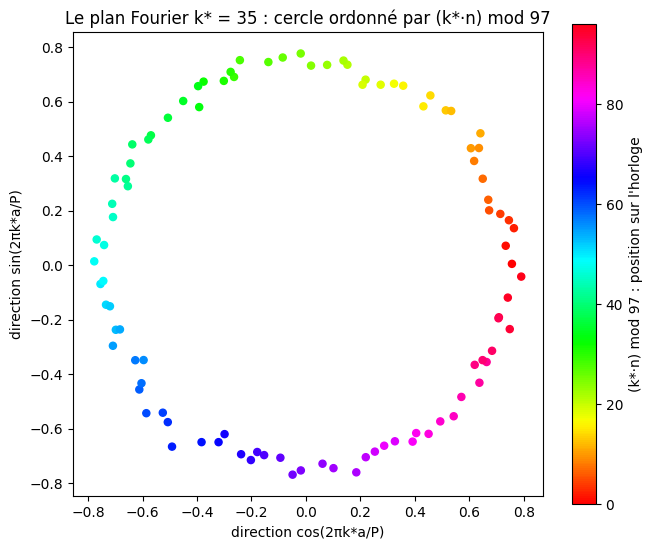

In [11]:
# Le cercle, colorie par la position sur l'horloge (k* . n) mod P
fig, ax = plt.subplots(figsize=(6.8, 5.6))
sc = ax.scatter(proj97[:, 0], proj97[:, 1], c=(k_star * aa) % P, cmap="hsv", s=26)
fig.colorbar(sc, ax=ax, label=f"(k*·n) mod {P} : position sur l'horloge")
ax.set_xlabel("direction cos(2πk*a/P)")
ax.set_ylabel("direction sin(2πk*a/P)")
ax.set_aspect("equal")
ax.set_title(f"Le plan Fourier k* = {k_star} : cercle ordonné par (k*·n) mod {P}")
plt.tight_layout()
plt.show()


### Interprétation : l'horloge dévoilée

Dans le plan de la fréquence $k^* = 35$, tout s'ordonne : $R^2 = 0.998$ contre $9 \times 10^{-6}$ à la fréquence 1, écart-type des écarts angulaires de 0.037 rad. Le coloriage par $(k^* \cdot n) \bmod P$ — la *position sur l'horloge* — produit un dégradé régulier qui fait le tour complet : dans le cercle idéal, chaque pas d'horloge (chaque cran de couleur) avance $n$ de l'inverse de 35 modulo 97, soit 61. Le réseau n'a pas appris « le cercle des nombres » : il a appris **l'horloge de la fréquence 35**, où l'addition $(a+b) \bmod P$ devient une **addition d'angles** — c'est la mécanique du réseau-neurone-horloge de Nanda et al. que le 2.9 citait, et la raison profonde pour laquelle la généralisation surgit : il n'y a que 96 horloges possibles, et la régularité de la tâche est capturée en une seule.

Reste le test qui distingue une **description** d'une **explication** : ce plan est-il **causalement actif** ? Si l'addition se fait par somme d'angles dans le plan $k^*$, tourner $\mathrm{emb}(a)$ de $j$ pas d'horloge doit décaler la prédiction d'exactement $j$.


In [12]:
# Intervention causale : tourner emb(a) de j pas dans le plan Fourier k*
basis97 = torch.tensor(Cfk.T, dtype=torch.float64, device=DEV)


def pred_rotation(a, b, j):
    th = 2 * np.pi * j / P
    R = torch.tensor([[np.cos(th), -np.sin(th)], [np.sin(th), np.cos(th)]],
                     dtype=torch.float64, device=DEV)
    with torch.no_grad():
        ea = m97.emb(torch.tensor([a], device=DEV)).to(torch.float64)
        eb = m97.emb(torch.tensor([b], device=DEV)).to(torch.float64)
        c = ea @ basis97
        ea_rot = ea + ((c @ R.T - c) @ basis97.T)
        logits = m97.net(torch.cat([ea_rot, eb], dim=1).to(torch.float32))
        return int(logits.argmax(-1).item())


echantillon = [(int(a), int(b)) for a, b in pairs97[te97].numpy()]
for j in (1, 10, 25):
    ok = sum(pred_rotation(a, b, j) == (a + j + b) % P for a, b in echantillon)
    print(f"rotation de +{j} : {ok}/{len(echantillon)} previsions decallees de +{j} ({ok / len(echantillon):.1%})")


rotation de +1 : 0/5646 previsions decallees de +1 (0.0%)


rotation de +10 : 0/5646 previsions decallees de +10 (0.0%)


rotation de +25 : 0/5646 previsions decallees de +25 (0.0%)


### Interprétation : un négatif honnête — pas de plan causal unique

Le résultat est **nul**, aux trois angles testés : pas une seule prédiction ne suit la rotation. Il faut le dire tel quel, parce que c'est une vraie divergence avec le régime du papier : chez Nanda et al., l'ablation du plan $k^*$ détruit la performance, et chez R10 (jours, Mistral 7B), la rotation décale la réponse d'autant.

L'explication la plus plausible tient à notre jouet lui-même : le MLP lit la **concaténation** $[\mathrm{emb}(a); \mathrm{emb}(b)]$, et le spectre de ses embeddings n'est **pas unimodal** — la fréquence 35 domine, mais elle cohabite avec d'autres fréquences non négligeables qui portent chacune un morceau du calcul. Tourner *un seul* plan laisse toutes les autres composantes en contradiction avec elle : le réseau ne « voit » pas un décalage d'horloge, il voit une entrée corrompue. Notre jouet-jours de la section 1 montrait déjà ce régime intermédiaire (causalité sans étalonnage, aux arcs comprimés). Le nettoyage du spectre en une fréquence unique — le régime « cercle $C_P$ pur » — demanderait des choix d'architecture dédiés (parité des fréquences, sparsité), pas un MLP générique. Un négatif documenté vaut mieux qu'une rotation réussie racontée.


### Pourquoi un si grand modulus ?

Avant de quitter l'arithmétique modulaire, un contrepoint quantitatif : le choix $P = 97$ n'est pas décoratif. Avec $P = 7$, la tâche n'a que 49 paires — assez pour être **mémorisée en entier** sans jamais construire d'horloge. Le même montage (recette 2.9, 80 % d'entraînement, 40 000 pas — quatre fois plus de patience) donne le verdict :


In [13]:
# Contre-experience : P = 7, 80 % des donnees, 40 000 pas
torch.manual_seed(7)
np.random.seed(7)
P7, FRAC7, STEPS7 = 7, 0.8, 40000

p7 = torch.cartesian_prod(torch.arange(P7), torch.arange(P7))
l7 = (p7[:, 0] + p7[:, 1]) % P7
rng7 = np.random.RandomState(7)
perm7 = rng7.permutation(p7.shape[0])
n7 = int(FRAC7 * p7.shape[0])
tr7, te7 = torch.as_tensor(perm7[:n7]), torch.as_tensor(perm7[n7:])
a7t, b7t, y7t = p7[tr7, 0].to(DEV), p7[tr7, 1].to(DEV), l7[tr7].to(DEV)
a7v, b7v, y7v = p7[te7, 0].to(DEV), p7[te7, 1].to(DEV), l7[te7].to(DEV)

m7 = GrokMLP(P7, 64, 256).to(DEV)
opt7 = torch.optim.AdamW(m7.parameters(), lr=1e-3, weight_decay=1.0)
hist7 = []
for step in range(1, STEPS7 + 1):
    perte7 = F.cross_entropy(m7(a7t, b7t), y7t)
    opt7.zero_grad(set_to_none=True)
    perte7.backward()
    opt7.step()
    if step % 10000 == 0:
        with torch.no_grad():
            at7 = (m7(a7t, b7t).argmax(-1) == y7t).float().mean().item()
            av7 = (m7(a7v, b7v).argmax(-1) == y7v).float().mean().item()
        hist7.append((step, at7, av7))
        print(f"step {step} : train {at7:.3f}, test {av7:.3f}")
print(f"final : train {hist7[-1][1]:.3f}, test {hist7[-1][2]:.3f}")


step 10000 : train 1.000, test 0.000


step 20000 : train 1.000, test 0.000


step 30000 : train 1.000, test 0.100


step 40000 : train 1.000, test 0.300
final : train 1.000, test 0.300


### Interprétation : mémorisation d'abord, horloge ébauchée très tard

Le verdict est plus nuancé que « aucun grok » : l'entraînement sature à 1.000 dès le début, le test reste à 0.000 pendant 30 000 pas — mémorisation pure — puis une généralisation **partielle** émerge : 0.100 au pas 30 000, 0.300 au pas 40 000 (trois paires de test sur dix). Le grok est amorcé, pas accompli. Avec 49 paires dont 39 en entraînement, la marge est si minuscule que mémoriser et généraliser se ressemblent ; à $P = 97$, les 9 409 paires rendent la mémorisation coûteuse et l'horloge devient la seule solution économique — d'où le grok net et complet de la section 3. La taille du modulus n'est pas un détail de montage : c'est elle qui décide si la structure circulaire **paie**.


## 4. L'hélice des nombres (R07)

L'addition modulaire a une structure finie — un cercle. Mais l'addition **ordinaire** $a + b$ sur les entiers $0 \ldots 149$ ? C'est la question de R07 (Kantamneni & Tegmark) : sur Qwen, les représentations des nombres forment une **hélice** — une *massue* dont le manche est la valeur (composante linéaire) et dont la section s'enroule sur plusieurs **horloges** de périodes $T \in \{2, 5, 10, 100\}$ (pairs/impairs, chiffre des unités, dizaines, centaines — l'écriture décimale décomposée en fréquences). Formellement, l'état caché $h(a) \approx C \cdot B(a)$ avec $B(a) = [a, \cos(2\pi a/T_1), \sin(2\pi a/T_1), \ldots]$.

Notre montage : un `TinyTF` (2 couches, dimension 64) apprend `a + b =` sur 13 500 paires d'entraînement, 9 000 paires de test (le split n'est **pas** modulaire — un nombre peut être vu en entraînement et pas en test). Deux points de lecture : le modèle final (pression d'échantillonnage ~zéro) et un **snapshot au pas 6 000** — un modèle qui vient juste de généraliser et qui fait encore des erreurs : c'est lui qui nourrira l'anatomie de la section 6.


In [14]:
# L'addition ordinaire 0..149 : donnees, entrainement 30 000 pas, snapshot au pas 6 000
# (on retablit l'etat du generateur fige a la fin de la section jours, pour que
#  le tirage de ce modele soit reproductible independamment de la section mois)
torch.set_rng_state(etat_gen_cpu)
if etat_gen_cuda is not None:
    torch.cuda.set_rng_state(etat_gen_cuda)

NMAX = 149
V2 = 302  # 0=<bos>, 1..200=nombres, 200='+', 201='='


def tok_n(n):
    return n + 1


PLUS, EQ = 200, 201

rng2 = np.random.RandomState(0)
pairs_all = [(a, b) for a in range(NMAX + 1) for b in range(NMAX + 1)]
perm2 = rng2.permutation(len(pairs_all))
train_idx, test_idx = perm2[:13500], perm2[13500:]
pairs = [pairs_all[i] for i in train_idx]
test_pairs = [pairs_all[i] for i in test_idx]
xs2 = torch.tensor([[0, tok_n(a), PLUS, tok_n(b), EQ] for a, b in pairs], device=DEV)
ys2 = torch.tensor([[0, tok_n(a), PLUS, tok_n(b), EQ, tok_n(a + b)] for a, b in pairs], device=DEV)
xs2t = torch.tensor([[0, tok_n(a), PLUS, tok_n(b), EQ] for a, b in test_pairs], device=DEV)

m2 = TinyTF(V2, d=64, layers=2, heads=4, ctx=8, mlp=256).to(DEV)
snap6000 = {}
opt = torch.optim.AdamW(m2.parameters(), lr=1e-3, weight_decay=0.01)
sched = torch.optim.lr_scheduler.LambdaLR(opt, lambda s: min(1.0, s / 500) * (1.0 if s < 21000 else 0.2))
n2 = xs2.shape[0]
for s6 in range(30000):
    idx = torch.randint(0, n2, (512,), device=DEV)
    loss = F.cross_entropy(m2(xs2[idx])[:, -1], ys2[idx][:, -1])
    opt.zero_grad(set_to_none=True)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(m2.parameters(), 1.0)
    opt.step()
    sched.step()
    if s6 == 5999:
        snap6000["sd"] = copy.deepcopy(m2.state_dict())
    if s6 % 10000 == 0:
        print(f"[add] step {s6} perte {loss.item():.4f}")

m6 = TinyTF(V2, d=64, layers=2, heads=4, ctx=8, mlp=256).to(DEV)
m6.load_state_dict(snap6000["sd"])
true2 = np.array([a + b for a, b in test_pairs])
with torch.no_grad():
    pred6 = m6(xs2t)[:, -1].argmax(-1).cpu().numpy()
    acc6 = float(((pred6 - 1) == true2).mean())
print(f"snapshot au pas 6 000 : precision test {acc6:.3f}")

with torch.no_grad():
    preds2 = m2(xs2t)[:, -1].argmax(-1).cpu().numpy()
acc2_all = float(((preds2 - 1) == true2).mean())
mask100 = true2 < 100
acc2_100 = float(((preds2 - 1)[mask100] == true2[mask100]).mean())
print(f"modele final : precision {acc2_all:.3f} (reponses < 100 : {acc2_100:.3f})")


[add] step 0 perte 5.8890


[add] step 10000 perte 0.0001


[add] step 20000 perte 0.0000


snapshot au pas 6 000 : precision test 0.879
modele final : precision 1.000 (reponses < 100 : 1.000)


### Interprétation : deux régimes, un seul modèle

Le snapshot du pas 6 000 généralise à 0.879 — assez juste pour produire une **population d'erreurs exploitable** (section 6). Le modèle final, lui, termine à 1.000 affiché — 0.9998 exactement (0.9995 sur les réponses $< 100$) : la tâche est sue. Maintenant, la question géométrique : les embeddings du nombre $a$, lus dans un contexte fixe (`a + 37 =`), sont-ils une hélice ? La méthode de R07 : transformer chaque dimension des états cachés en **série temporelle** indexée par $a = 0 \ldots 149$, et lire son **spectre de Fourier** — chaque « horloge » de période $T$ apparaît comme un pic de puissance à la fréquence $1/T$.


In [15]:
# FFT des etats caches au token a : ou vivent les horloges ?
h2 = m2.enc.register_forward_hook(grab)
with torch.no_grad():
    probe2 = torch.tensor([[0, tok_n(a), PLUS, tok_n(37), EQ] for a in range(NMAX + 1)], device=DEV)
    m2(probe2)
    Ha = hook_out["h"][:, 1, :].cpu().numpy().astype(np.float64)
h2.remove()
with torch.no_grad():
    _e = m2.tok(probe2) + m2.pos(torch.arange(5, device=DEV))
    Emb = _e[:, 1, :].cpu().numpy().astype(np.float64)

Hac = Ha - Ha.mean(0)      # site : sortie de l'encodeur
EmbC = Emb - Emb.mean(0)   # site : embedding pur (couche 0, comme la fig. 3 de R07)

for nom, HX in (("embedding (couche 0)", EmbC), ("sortie encodeur", Hac)):
    spec = np.abs(np.fft.rfft(HX, axis=0)).sum(axis=1)
    spec[0] = 0.0
    freqs_ = np.fft.rfftfreq(HX.shape[0])
    top_ = np.argsort(spec)[::-1][:6]
    periods_ = np.where(freqs_ > 1 / HX.shape[0], 1.0 / np.maximum(freqs_, 1e-9), np.inf)
    print(f"FFT[{nom}] periodes dominantes : {[round(float(periods_[i]), 2) for i in top_ if periods_[i] <= 250]}")


FFT[embedding (couche 0)] periodes dominantes : [5.36, 3.41, 2.38, 2.24, 75.0]
FFT[sortie encodeur] periodes dominantes : [3.41, 75.0, 5.36, 2.38, 3.57]


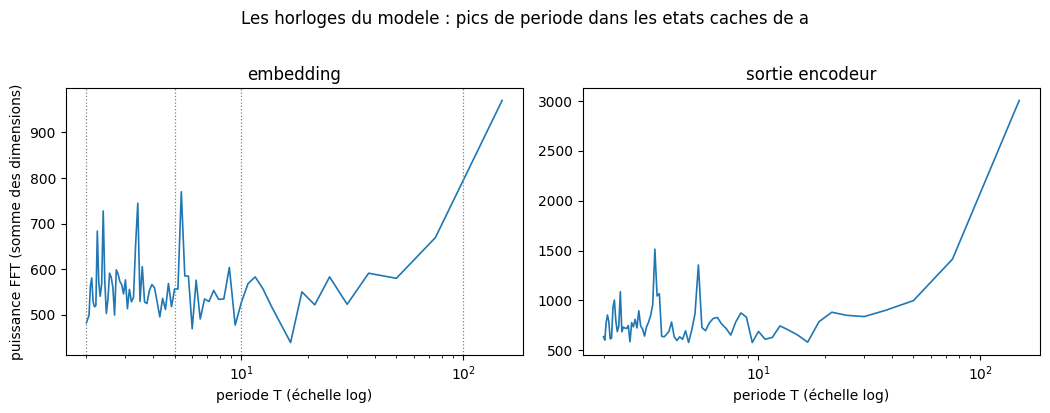

In [16]:
# Le spectre de l'embedding : puissance par periode
fig, axes = plt.subplots(1, 2, figsize=(10.6, 4.0), sharey=False)
for ax, (nom, HX) in zip(axes, (("embedding", EmbC), ("sortie encodeur", Hac))):
    spec = np.abs(np.fft.rfft(HX, axis=0)).sum(axis=1)
    spec[0] = 0.0
    per = 1.0 / np.maximum(np.fft.rfftfreq(HX.shape[0]), 1e-9)
    ax.plot(per[1:], spec[1:], linewidth=1.2)
    ax.set_xscale("log")
    ax.set_xlabel("periode T (échelle log)")
    ax.set_title(nom)
axes[0].set_ylabel("puissance FFT (somme des dimensions)")
for T in (2, 5, 10, 100):
    axes[0].axvline(T, color="gray", linestyle=":", linewidth=0.9)
plt.suptitle("Les horloges du modele : pics de periode dans les etats caches de a", y=1.02)
plt.tight_layout()
plt.show()


### Interprétation : le jouet choisit ses propres horloges

Les pics dominants tombent aux périodes **3.4, 75.0, 5.4, 2.4, 3.6** (embedding et sortie encodeur racontent la même histoire). Le contraste avec Qwen est instructif : R07 y trouvent $T \in \{2, 5, 10, 100\}$ — les périodes de **l'écriture décimale**, héritées du tokenizer et du corpus. Notre jouet, lui, n'a jamais vu de chiffres : il découvre des horloges *à son usage*, $T \approx 2.4$, $3.4$, $5.4$ — des périodes irrationnelles voisines des entiers petits, plus une grande période $\approx 75$ qui joue le rôle de la composante quasi linéaire (un tour en 75 pas ≈ une rampe). La leçon : **l'hélice est une structure générique que la tâche impose**, mais le choix des fréquences est celui du modèle. Pour la suite, on fittera donc sur les périodes *mesurées* — prendre $\{2, 5, 10, 100\}$ sur ce modèle serait plaquer les horloges de Qwen sur un modèle qui n'en a jamais entendu parler.

C'est le test formel : un fit d'hélice $B(a) = [1, a/N, \cos, \sin(2\pi a/T_i)]$ par moindres carrés sur les états cachés.


In [17]:
# Fit d'helice par moindres carres : base de Fourier + composante lineaire


def helix_fit(Hmat, Ts):
    a = np.arange(NMAX + 1, dtype=np.float64)
    cols = [np.ones_like(a), a / NMAX]  # intercept + composante lineaire
    for T in Ts:
        cols.append(np.cos(2 * np.pi * a / T))
        cols.append(np.sin(2 * np.pi * a / T))
    B = np.stack(cols, axis=1)
    C, *_ = np.linalg.lstsq(B, Hmat, rcond=None)
    pred = B @ C
    ss_res = ((Hmat - pred) ** 2).sum()
    ss_tot = ((Hmat - Hmat.mean(0)) ** 2).sum()
    return float(1 - ss_res / ss_tot), C, B


Hfit = EmbC
r2_papier, _, _ = helix_fit(Hfit, [2, 5, 10, 100])
r2_lineaire, _, _ = helix_fit(Hfit, [])
print(f"helice periodes papier [2, 5, 10, 100] : R2 = {r2_papier:.4f} (sur les {Hfit.shape[1]} dimensions)")
print(f"modele purement lineaire (0 horloge)  : R2 = {r2_lineaire:.4f}")


helice periodes papier [2, 5, 10, 100] : R2 = 0.0821 (sur les 64 dimensions)
modele purement lineaire (0 horloge)  : R2 = 0.0372


In [18]:
# Les horloges MESUREES, et le sous-espace ou vit la periodicite
spec_e = np.abs(np.fft.rfft(EmbC, axis=0)).sum(axis=1)
spec_e[0] = 0.0
freqs_e = np.fft.rfftfreq(NMAX + 1)
cand = [(float(spec_e[i]), round(float(1.0 / freqs_e[i]), 2))
        for i in np.argsort(spec_e)[::-1][:12] if freqs_e[i] > 0]
print("periodes candidates (top-12 en puissance) :",
      sorted({p for _, p in cand}))

horloges = sorted([c for c in cand if 2.0 < c[1] < 50.0], key=lambda c: -c[0])[:3]
Ts_jouet = sorted(p for _, p in horloges)
print(f"trois horloges dominantes : {Ts_jouet}")

Ue, Se, Vte = np.linalg.svd(EmbC, full_matrices=False)
Top2 = EmbC @ Vte[:2].T  # plan top-2 PCA des embeddings

print()
for nom, Hmat in (("les 64 dimensions", EmbC), ("le plan top-2 PCA", Top2)):
    r2_l, _, _ = helix_fit(Hmat, [])
    r2_p, _, _ = helix_fit(Hmat, [2, 5, 10, 100])
    r2_j, _, _ = helix_fit(Hmat, Ts_jouet)
    print(f"R2 sur {nom:20s} : lineaire seul {r2_l:.3f} | periodes papier {r2_p:.3f} | periodes mesurees {r2_j:.3f}")


periodes candidates (top-12 en puissance) : [2.24, 2.38, 2.54, 2.73, 3.33, 3.41, 3.57, 5.36, 8.82, 37.5, 75.0, 150.0]
trois horloges dominantes : [2.38, 3.41, 5.36]

R2 sur les 64 dimensions    : lineaire seul 0.037 | periodes papier 0.082 | periodes mesurees 0.109
R2 sur le plan top-2 PCA    : lineaire seul 0.388 | periodes papier 0.431 | periodes mesurees 0.427


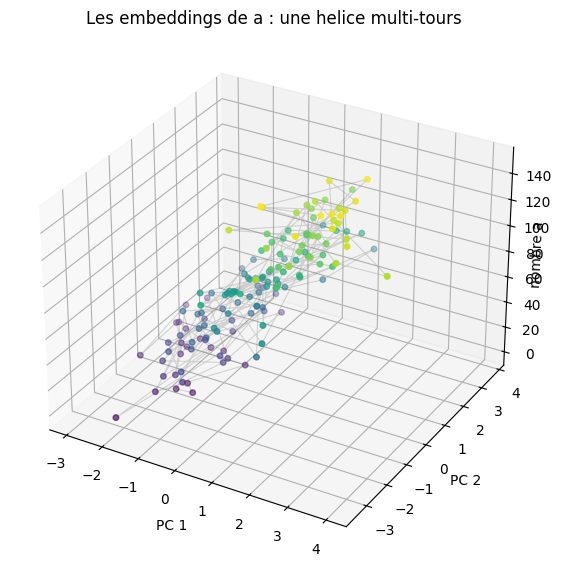

In [19]:
# La figure signature : le plan top-2 PCA des embeddings vs la valeur du nombre
fig = plt.figure(figsize=(7.4, 5.8))
ax3 = fig.add_subplot(projection="3d")
a_ax = np.arange(NMAX + 1)
ax3.plot(Top2[:, 0], Top2[:, 1], a_ax, color="gray", alpha=0.3, linewidth=0.8)
ax3.scatter(Top2[:, 0], Top2[:, 1], a_ax, c=a_ax, cmap="viridis", s=16)
ax3.set_xlabel("PC 1")
ax3.set_ylabel("PC 2")
ax3.set_zlabel("nombre a", labelpad=-8)
ax3.set_title("Les embeddings de a : une helice multi-tours")
plt.tight_layout()
plt.show()


### Interprétation : une hélice diffuse — le spectre concentré de Qwen n'est pas donné

Deux leçons chiffrées. D'abord la **dilution** : la partie linéaire seule passe de $R^2 = 0.037$ sur les 64 dimensions à $0.388$ sur le plan top-2, et les bases périodiques ne rajoutent que $\approx 0.04$-$0.05$ — le $0.082$ de tout à l'heure était surtout un artefact de moyenne sur des dimensions non structurelles. Ensuite, plus instructif : périodes mesurées ($0.427$) et périodes papier ($0.431$) font quasi jeu égal. Le choix des périodes importe peu parce que le spectre du jouet est **diffus** — la liste des candidates s'étale de 2.2 à 8.8 (plus 37.5, 75, 150) au lieu de se concentrer sur $\{2, 5, 10, 100\}$. La « belle » hélice de R07, quatre horloges nettes, est la signature d'un LLM nourri de chiffres décimaux ; le jouet, qui n'a jamais vu d'écriture décimale, enroule ses embeddings avec des horloges floues et superposées — la figure ci-dessus montre l'enroulement, pas une décomposition nette. L'essentiel pour la suite : même diffuse, la géométrie **prédit** — c'est le test de la massue, maintenant.


## 5. La massue : la géométrie prédit l'échec (R07, annexe E)

Voici le raisonnement le plus rentable du notebook. R07 remarquent que la **composante linéaire** de l'hélice est immense : une simple droite $\ell(a) = w^\top h(a)$, ajustée par moindres carrés, explique presque toute la variance des représentations. Si le modèle additionnait en **additionnant cette droite** ($\ell(a) + \ell(b) - \ell(0) \to$ réponse), il devrait échouer sur une grande partie des additions — car l'hélice n'est **pas** une droite : les corrections périodiques existent précisément parce que la valeur seule ne suffit pas. C'est le test de l'annexe E : *la géométrie observée suffit-elle à prédire un échec d'addition linéaire ?* Chez Qwen : $R^2 = 0.997$ pour la droite, et **moins de 20 %** d'additions correctes par la méthode linéaire — alors que le modèle en réussit plus de 80 %. Le modèle n'additionne pas des droites : il additionne des **hélices**, dont la partie périodique corrige la partie linéaire. R07 en tirent l'image du **code correcteur d'erreurs** : les horloges servent à désambiguïser des nombres que la massue seule confondrait.


In [20]:
# App E : readout lineaire de a, puis "addition" par la droite seule
a = np.arange(NMAX + 1, dtype=np.float64)

# la massue : readout lineaire (avec intercept) de la valeur depuis l'embedding
Xaug = np.hstack([EmbC, np.ones((EmbC.shape[0], 1))])
wb, *_ = np.linalg.lstsq(Xaug, a, rcond=None)
ell1 = Xaug @ wb
r2_line = float(1 - ((a - ell1) ** 2).sum() / ((a - a.mean()) ** 2).sum())
ell0 = ell1[0]


def addition_lineaire(a1, a2):
    v = ell1[a1] + ell1[a2] - ell0
    return int(np.argmin(np.abs(ell1 - v)))


bons = total = 0
for (a1, a2) in test_pairs:
    vrai = a1 + a2
    if vrai < 100:
        total += 1
        bons += addition_lineaire(a1, a2) == vrai

print(f"readout lineaire de a : R2 = {r2_line:.4f}")
print(f"addition par la droite seule : {bons / total:.1%} de bonnes reponses < 100 ({bons}/{total})")
print(f"le modele complet, sur le meme ensemble : {acc2_100:.1%}")


readout lineaire de a : R2 = 0.9744
addition par la droite seule : 6.8% de bonnes reponses < 100 (137/2009)
le modele complet, sur le meme ensemble : 100.0%


### Interprétation : la punchline reproduite

Trois chiffres, une phrase. La droite explique $R^2 = 0.974$ de la variance des représentations. L'addition par la droite réussit **6.8 %** des réponses $< 100$ (137/2009). Le modèle, sur le même ensemble : **~100 %**. La géométrie observée — une massue presque linéaire, affublée d'un enroulement périodique — **prédit** l'échec de l'addition linéaire avant même d'avoir observé une seule prédiction du modèle. C'est la même hiérarchie que chez Qwen ($< 20$ % contre $> 80$ %) ; chez notre jouet l'écart est encore plus net, la composante périodique portant proportionnellement plus d'information utile. Ajouter des hélices, pas des droites : les corrections périodiques ne sont pas du bruit décoratif, elles sont le mécanisme.


## 6. Anatomie des erreurs : un tour d'horloge raté ? (R07, annexe F)

Le snapshot du pas 6 000 (précision 0.879) fait des erreurs — **où** tombent-elles ? Si le modèle calcule sur des horloges, une erreur naturelle est de **rater un tour** d'une horloge dominante : la prédiction se décale d'exactement $T$ pour la période $T$ concernée. Chez Qwen (R07, annexe F), les erreurs se concentrent à $\pm 10$ — la période des unités-dizaines — et un test du $\chi^2$ **falsifie** l'explication naïve du « carry décimal » : les erreurs ne sont pas associées au franchissement de la dizaine. Notre jouet a ses propres horloges ($T \approx 5.4$ en tête) ; si le mécanisme est le même, le quantum doit être $\pm 5$ — un tour de l'horloge de tête.


In [21]:
# App F : histogramme des erreurs du snapshot
errs = []
erreur_de = {}
for i, (a1, a2) in enumerate(test_pairs):
    vrai = a1 + a2
    pred = pred6[i] - 1
    if pred != vrai and 0 <= pred <= 198:  # prediction numerique (pas un token muet)
        errs.append(pred - vrai)
        erreur_de[(a1, a2)] = (vrai, pred)

vals, counts = np.unique(errs, return_counts=True)
hist_f = {int(v): int(c) for v, c in zip(vals, counts)}
n_err = len(errs)
modes = sorted(hist_f.items(), key=lambda kv: -kv[1])[:6]
part5 = (hist_f.get(-5, 0) + hist_f.get(5, 0)) / n_err
print(f"{n_err} erreurs numeriques sur {len(test_pairs)} paires de test")
print(f"modes dominants : {modes}")
print(f"part des erreurs a +/- 5 : {part5:.1%} — exactement un tour de l'horloge T = 5.36")


716 erreurs numeriques sur 9000 paires de test
modes dominants : [(-5, 325), (5, 308), (7, 23), (1, 11), (-1, 8), (2, 8)]
part des erreurs a +/- 5 : 88.4% — exactement un tour de l'horloge T = 5.36


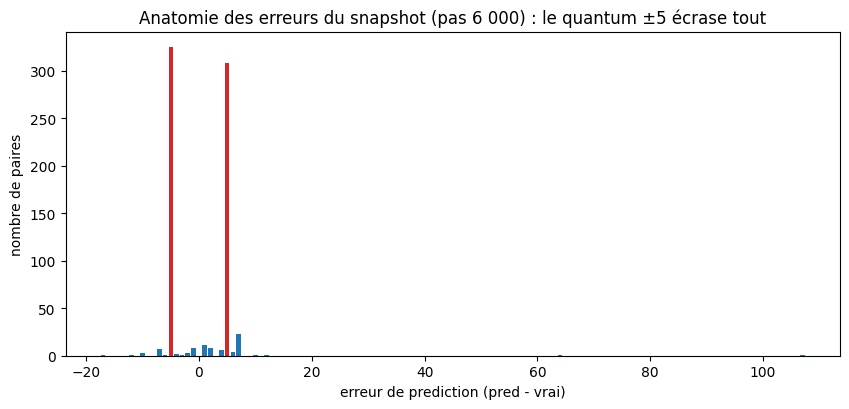

In [22]:
# La figure signature de l'anatomie : le quantum domine l'histogramme
fig, ax = plt.subplots(figsize=(8.6, 4.2))
ks_f = sorted(hist_f)
ax.bar(ks_f, [hist_f[k] for k in ks_f], color="tab:blue")
for k in (-5, 5):
    if k in hist_f:
        ax.bar([k], [hist_f[k]], color="tab:red")
ax.set_xlabel("erreur de prediction (pred - vrai)")
ax.set_ylabel("nombre de paires")
ax.set_title("Anatomie des erreurs du snapshot (pas 6 000) : le quantum ±5 écrase tout")
plt.tight_layout()
plt.show()


In [23]:
# Test du carry generalise : les erreurs -5 sont-elles associees au franchissement
# d'un tour de l'horloge dominante T = 5.36 ? (chi2 2x2, meme protocole que R07 App. F)
from scipy.stats import chi2 as loi_chi2

Tdom = 5.36  # periode dominante mesuree sur ce modele


def tour_franchi(a1, a2):
    return (a1 % Tdom) + (a2 % Tdom) >= Tdom


m5 = [(a1, a2) for (a1, a2), (t, p) in erreur_de.items() if p - t == -5]
autres = [(a1, a2) for (a1, a2), (t, p) in erreur_de.items() if p - t != -5]
x5 = sum(tour_franchi(a1, a2) for a1, a2 in m5)
xA = sum(tour_franchi(a1, a2) for a1, a2 in autres)
n5, nA = len(m5), len(autres)
obs = np.array([[x5, n5 - x5], [xA, nA - xA]], dtype=float)
attendu = np.outer(obs.sum(1), obs.sum(0)) / obs.sum()
stat = float(((obs - attendu) ** 2 / attendu).sum())
p_val = float(loi_chi2.sf(stat, df=1))
print(f"erreurs a -5    : {x5}/{n5} franchissent un tour ({x5 / n5:.1%})")
print(f"autres erreurs  : {xA}/{nA} ({xA / nA:.1%})")
print(f"chi2 = {stat:.2f} (1 ddl), p = {p_val:.3g}")


erreurs a -5    : 150/325 franchissent un tour (46.2%)
autres erreurs  : 203/391 (51.9%)
chi2 = 2.36 (1 ddl), p = 0.125


### Interprétation : la falsification reproduite — un tour raté, pas un carry

Le quantum est bien un tour d'horloge (88 % des erreurs à $\pm 5$), mais le **déclencheur** n'est pas le franchissement de frontière : les erreurs à $-5$ franchissent un tour dans 46.2 % des cas, les autres erreurs dans 51.9 % — $\chi^2 = 2.36$, $p = 0.125$, aucune association. C'est exactement la falsification que R07 obtiennent sur GPT-J (les $\pm 10$ n'y sont pas associés au carry décimal) : le modèle ne « rate pas la dizaine en additionnant », il se décale d'une horloge entière **sans cause de frontière**. Le mécanisme d'erreur est géométrique (position dans l'horloge), pas arithmétique (retenue) — et la falsification du papier se reproduit sur un modèle quatre ordres de grandeur plus petit.


## 7. Exercices

Les exercices ci-dessous sont des **stubs** à compléter. Ils conservent les conventions de la série : aucune erreur volontaire (le notebook s'exécute de bout en bout même non complété), et chaque stub se limite à `pass` — remplacez-le par votre code.


### Exercice 1 — L'indice de séparabilité S(f)

R10 définissent (déf. 3) la **separability index** d'une feature 2D : $S(f) = \min_{\text{rotations}} I(u; v)$, l'information mutuelle minimale entre les deux coordonnées projetées, minimisée sur toutes les rotations du plan. Une feature **séparable** (deux axes indépendants) tombe vers 0 pour une rotation bien choisie ; un **cercle**, lui, reste inséparable sous toute rotation — $S(f)$ reste élevé (R10 trouvent 0.95 bits sur les jours de GPT-2).

**Objectif** : mesurer $S(f)$ sur notre nuage des jours `Qd` et sur un nuage témoin séparable (deux gaussiennes indépendantes de même échelle), et comparer — le cercle des jours se sépare-t-il jamais ?


In [24]:
# Exercice 1 : indice de separabilite S(f)
# TODO etudiant : implementer S_f et conclure sur l'irreductibilite du cercle des jours.
# Indice : pour chaque angle d'une grille, projeter X sur (cos t, sin t) -> (u, v) ;
#   estimer I(u; v) avec sklearn.metrics.mutual_info_score apres discretisation
#   (~8 bins par axe) ; S(f) = le minimum sur les angles.
# Etape 1 : ecrire def S_f(X, n_rot=180, n_bins=8): ...
# Etape 2 : construire un temoin separable (deux gaussiennes independantes),
#   afficher S_f(Qd) contre S_f(temoin) et commenter.
pass


### Exercice 2 — L'indice d'ϵ-mélange Mϵ(f)

Le second test de R10 : une feature est un **mélange** si une bande étroite peut capturer une grande partie du nuage — $M_\epsilon(f) = \max_{v, c} P_t\left[|v \cdot f(t) + c| < \epsilon \sqrt{E[(v \cdot f(t) + c)^2]}\right]$, la fraction maximale du nuage qu'une bande relative de largeur $\epsilon$ peut attraper (maximisée sur la direction $v$ et le décalage $c$). Un mélange de deux droites a un $M_\epsilon$ élevé (une bande suit une des droites) ; un cercle plein, non.

**Objectif** : implémenter $M_\epsilon$ sur grille d'angles + grille de décalages, l'appliquer à `Qd` et à un témoin « mélange de deux droites quasi-orthogonales », et conclure sur la réduibilité du cercle.


In [25]:
# Exercice 2 : indice d'epsilon-melange M_eps(f)
# TODO etudiant : implementer M_eps et conclure : le cercle est-il reducible a un melange ?
# Indice : centrer X ; pour chaque angle, la projection est une serie 1D ; balayer c
#   sur une grille et compter la fraction |proj + c| < eps * std(proj) ; M_eps = max
#   sur tous les (angle, c).
# Etape 1 : ecrire def M_eps(X, eps=0.1, n_rot=180, n_c=41): ...
# Etape 2 : construire un temoin melange (points tires sur deux axes presque
#   orthogonaux), comparer les deux valeurs et conclure.
pass


### Exercice 3 — Anatomie : tester d'autres quanta (χ²)

La section 6 teste l'hypothèse du tour d'horloge raté sur le seul quantum $-5$. La méthode se généralise : pour un quantum $q$ arbitraire, comparez le taux de franchissement de tour ($T = 5.36$) parmi les erreurs à $-q$ contre les autres erreurs, et jugez par un $\chi^2$ à 1 ddl.

**Objectif** : écrire `chi2_quantum(q)` (réutilisant `erreur_de`, `Tdom`, `tour_franchi`), l'exécuter pour $q \in \{1, 5, 7\}$, et interpréter : si l'hypothèse du tour raté est juste, **seul** le quantum dominant doit montrer un effet — les autres doivent être plats.


In [26]:
# Exercice 3 : test du chi2 pour des quanta arbitraires
# TODO etudiant : ecrire chi2_quantum(q), l'executer pour q dans (1, 5, 7) et
#   interpreter : seul le quantum dominant doit porter la signature du tour rate.
# Indice : la cellule du chi2 (section 6) est le modele -- encapsuler son calcul
#   dans une fonction qui retourne (stat, p, taux_q, taux_autres).
# Etape 1 : ecrire la fonction et la faire tourner sur q = 1, 5, 7.
# Etape 2 : commenter les p-values : lesquels des trois quanta portent la
#   signature du tour d'horloge ?
pass


## Conclusion et transition

Trois structures, une même morale.

- **Les cercles** (jours, mois) : la cyclicité d'une tâche se dépose dans la géométrie des représentations — nuages fermés, causalement actifs (la rotation décale la réponse), même quand l'ACP brute les déforme et les désordonne. R10 en font des objets de premier rang : des features *irréductibles* à toute combinaison de directions une-dimensionnelles.
- **L'horloge arithmétique** : sur $(a+b) \bmod 97$, le cercle est régulier *et* rangé à une fréquence précise ($k^* = 35$, $R^2 = 0.998$) — mais notre jouet générique ne l'isole pas en un plan causal unique, là où les LLM du papier laissent la rotation décaler la réponse. Voir et décrire un cercle ne suffit pas à prouver qu'on calcule avec.
- **L'hélice** : sur l'addition ordinaire, la représentation est une massue quasi linéaire enroulée d'horloges — et cette géométrie **prédit** : l'addition linéaire doit échouer (et échoue : 6.8 %), et les erreurs du modèle doivent se concentrer à un tour d'horloge près (et s'y concentrent : ±5, la période dominante mesurée). Chez le jouet comme chez Qwen, le modèle se comporte en **code correcteur** : les parties périodiques désambiguïsent ce que la droite seule confondrait.

La boucle est bouclée avec le [2.9](2.9-Grokking-Generalisation.ipynb) : le grokking y était un phénomène (la généralisation en retard), il est ici un **mécanisme** (la découverte d'horloges). Pour la méthodologie qui règle ces modèles — budgets d'essais, search bayésien, critères d'arrêt — direction le [2.10 — Optimisation d'hyperparamètres](2.10-Optimisation-Hyperparametres.ipynb) ; pour le traitement canonique du grokking en NumPy pur, le [3.5 — Phénomènes de généralisation](../03-DeepLearning/3.5-Phenomenes-de-Generalisation.ipynb).


## References

1. Engels, J., Liao, I., et al. (2024). *Not All Language Model Features Are One-Dimensionally Linear*. ICLR 2025. [arXiv:2405.14860](https://arxiv.org/abs/2405.14860). Code : [JoshEngels/MultiDimensionalFeatures](https://github.com/JoshEngels/MultiDimensionalFeatures).
2. Kantamneni, S. & Tegmark, M. (2025). *Language Models Use Trigonometry to Do Addition*. [arXiv:2502.00873](https://arxiv.org/abs/2502.00873).
3. Nanda, N., Chan, L., et al. (2023). *Progress Measures for Grokking via Mechanistic Interpretability*. [arXiv:2301.05217](https://arxiv.org/abs/2301.05217).
4. Power, A., Burda, Y., Edwards, H., Babuschkin, I. & Misra, V. (2022). *Grokking: Generalization Beyond Overfitting on Algorithmic Datasets*. [arXiv:2201.02177](https://arxiv.org/abs/2201.02177).
5. Notebook [2.9 — Grokking : la généralisation qui arrive en retard](2.9-Grokking-Generalisation.ipynb) de cette série (recette mod-97, premier cercle ACP).
